# Drug Response Prediction — Exploratory Analysis

This notebook walks through:
1. Dataset exploration & distributions
2. Feature correlations
3. Model training & evaluation
4. SHAP explainability
5. Personalized treatment simulation

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Generate & Load Data

In [2]:
from src.data_generator import generate_patient_data

df = generate_patient_data(1200)
print(f'Shape: {df.shape}')
df.head()

Shape: (1200, 18)


,patient_id,age,gender,weight_kg,bmi,creatinine,egfr,alt_liver_enzyme,albumin,hemoglobin,BRCA1_mut,CYP2D6_pm,EGFR_mut,KRAS_mut,TP53_mut,drug_assigned,response_score,response_label
0,P0000,62,Male,70.3,23.29,1.67,81.2,31.1,2.99,12.8,1,0,1,0,0,DrugB,65.73,Responder
1,P0001,48,Female,63.3,22.80,0.94,100.4,37.0,3.62,12.2,0,0,0,0,1,DrugA,49.31,Non-Responder
2,P0002,45,Female,59.5,19.16,0.79,115.3,39.9,3.81,10.3,1,0,0,0,0,DrugA,64.77,Responder
3,P0003,57,Female,72.4,19.80,1.20,110.8,41.7,4.04,9.7,0,1,1,0,0,DrugD,64.43,Responder
4,P0004,70,Male,83.2,26.98,1.16,90.6,37.4,3.92,15.2,1,0,0,0,0,DrugB,48.56,Non-Responder


## 2. Exploratory Data Analysis

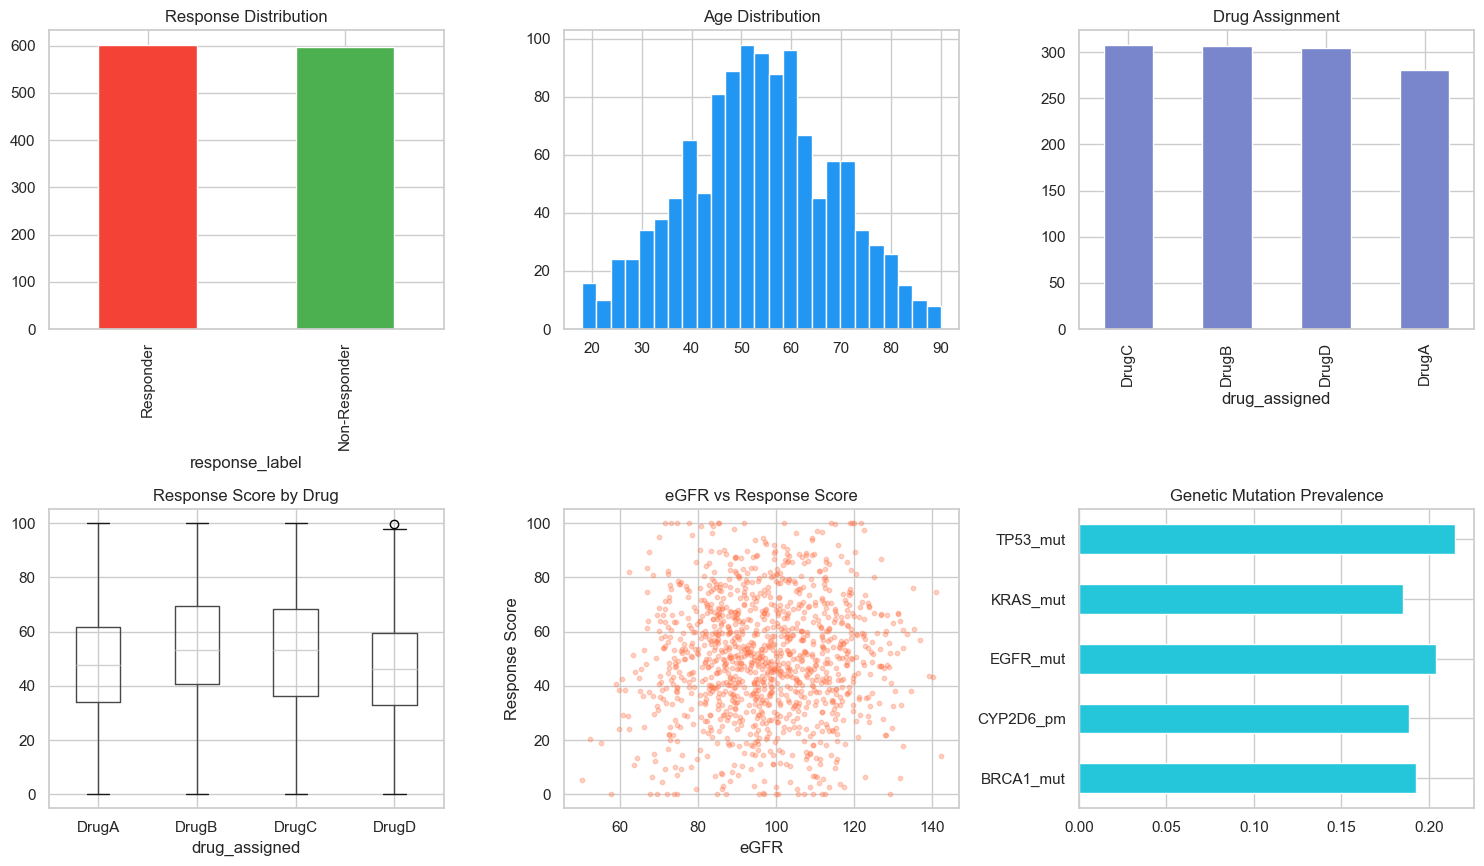

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Response distribution
df['response_label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#f44336','#4CAF50'])
axes[0,0].set_title('Response Distribution')

# Age histogram
df['age'].hist(bins=25, ax=axes[0,1], color='#2196F3')
axes[0,1].set_title('Age Distribution')

# Drug distribution
df['drug_assigned'].value_counts().plot(kind='bar', ax=axes[0,2], color='#7986CB')
axes[0,2].set_title('Drug Assignment')

# Response score by drug
df.boxplot(column='response_score', by='drug_assigned', ax=axes[1,0])
axes[1,0].set_title('Response Score by Drug')

# eGFR vs response score
axes[1,1].scatter(df['egfr'], df['response_score'], alpha=0.3, c='#FF7043', s=10)
axes[1,1].set_xlabel('eGFR'); axes[1,1].set_ylabel('Response Score')
axes[1,1].set_title('eGFR vs Response Score')

# Genetic mutation prevalence
gene_cols = ['BRCA1_mut','CYP2D6_pm','EGFR_mut','KRAS_mut','TP53_mut']
df[gene_cols].mean().plot(kind='barh', ax=axes[1,2], color='#26C6DA')
axes[1,2].set_title('Genetic Mutation Prevalence')

plt.suptitle('', y=0)
plt.tight_layout()
plt.show()

## 3. Train Models

In [4]:
import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)
df.to_csv('../data/patient_data.csv', index=False)

from src.train import train_and_evaluate
model, results, feature_cols = train_and_evaluate(
    data_path='../data/patient_data.csv',
    model_dir='../models/'
)

Dataset: 1200 patients | Response rate: 50.2%
Preprocessing artifacts saved.

--- Model Comparison ---

Logistic Regression (Baseline)
  CV AUC:  0.5948 ± 0.0368
  Test AUC: 0.5467 | Acc: 0.5500 | F1: 0.5424

Random Forest
  CV AUC:  0.6089 ± 0.0256
  Test AUC: 0.6109 | Acc: 0.5583 | F1: 0.5827

Gradient Boosting
  CV AUC:  0.5806 ± 0.0350
  Test AUC: 0.6145 | Acc: 0.5917 | F1: 0.5984

SVM
  CV AUC:  0.6051 ± 0.0144
  Test AUC: 0.5759 | Acc: 0.5458 | F1: 0.5439

✓ Best model: Gradient Boosting (AUC=0.6145)

All artifacts saved to '../models/'


## 4. SHAP Feature Importance

In [6]:
from src.explainability import run_shap_analysis
import os; os.makedirs('../models', exist_ok=True)
shap_values, importance_df = run_shap_analysis(
    data_path='../data/patient_data.csv',
    model_dir='../models/'
)
print(importance_df)

Computing SHAP values (this may take a moment)...
SHAP summary plot saved: ../models/shap_summary.png
SHAP bar chart saved: ../models/shap_bar.png

Top 10 features:
          feature  mean_abs_shap
          albumin       0.091467
              age       0.097730
              bmi       0.107659
        weight_kg       0.111628
         EGFR_mut       0.116852
       creatinine       0.157565
       hemoglobin       0.164100
drug_assigned_enc       0.165213
             egfr       0.166554
 alt_liver_enzyme       0.167665
              feature  mean_abs_shap
14         gender_enc       0.049154
9           CYP2D6_pm       0.053321
13     genetic_burden       0.063556
8           BRCA1_mut       0.065260
17      age_group_enc       0.089653
6             albumin       0.091467
0                 age       0.097730
2                 bmi       0.107659
1           weight_kg       0.111628
10           EGFR_mut       0.116852
3          creatinine       0.157565
7          hemoglobin       

## 5. Personalized Treatment Simulation

In [7]:
import joblib
from src.preprocessing import load_artifacts, engineer_features

model = joblib.load('../models/best_model.pkl')
scaler, encoders = load_artifacts('../models/')

# Define a hypothetical patient
patient_base = {
    'age': 58, 'gender': 'Female', 'weight_kg': 68, 'bmi': 24.5,
    'creatinine': 1.1, 'egfr': 72, 'alt_liver_enzyme': 38,
    'albumin': 4.1, 'hemoglobin': 12.8,
    'BRCA1_mut': 1, 'CYP2D6_pm': 0, 'EGFR_mut': 0,
    'KRAS_mut': 0, 'TP53_mut': 1,
}

drugs = ['DrugA', 'DrugB', 'DrugC', 'DrugD']
print('Personalized Treatment Recommendations:')
print('-' * 42)

probs = {}
for drug in drugs:
    p = {**patient_base, 'drug_assigned': drug, 'response_label': 'Responder', 'response_score': 50}
    df_p = pd.DataFrame([p])
    df_p = engineer_features(df_p)
    cat_cols = ['gender','drug_assigned','renal_function','age_group','bmi_category']
    for col in cat_cols:
        le = encoders[col]
        val = str(df_p[col].iloc[0])
        df_p[col+'_enc'] = le.transform([val])[0] if val in le.classes_ else 0

    gene_cols = ['BRCA1_mut','CYP2D6_pm','EGFR_mut','KRAS_mut','TP53_mut']
    clinical = ['age','weight_kg','bmi','creatinine','egfr','alt_liver_enzyme','albumin','hemoglobin']
    encoded_cats = [c+'_enc' for c in cat_cols]
    feat = clinical + gene_cols + ['genetic_burden'] + encoded_cats
    X_p = scaler.transform(df_p[feat].values)

    prob = model.predict_proba(X_p)[0][1]
    probs[drug] = prob
    tag = '✅ RECOMMEND' if prob >= 0.5 else '❌ Avoid'
    print(f'{drug:8s}: {prob*100:5.1f}% response probability  {tag}')

best = max(probs, key=probs.get)
print(f'\n⭐ Best option: {best} ({probs[best]*100:.1f}%)')

Personalized Treatment Recommendations:
------------------------------------------
DrugA   :  62.6% response probability  ✅ RECOMMEND
DrugB   :  63.7% response probability  ✅ RECOMMEND
DrugC   :  72.0% response probability  ✅ RECOMMEND
DrugD   :  56.7% response probability  ✅ RECOMMEND

⭐ Best option: DrugC (72.0%)
